In [1]:
# 1. IMPORT LIBRARIES
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# 2. LOAD DATASET
df = pd.read_csv('https://query.data.world/s/442hmws6ei6qe3xfgbp6tdemtxxz7p')

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [6]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [7]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
# CUSTOMER CHURN COUNT
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [10]:
# CHURN PERCENTAGE
churn_percent = 100 * df['Churn'].value_counts(normalize=True)
churn_percent

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [11]:
# GENDER DISTRIBUTION
df['gender'].value_counts()

gender
Male      3555
Female    3488
Name: count, dtype: int64

In [31]:
# AVERAGE MONTHLY CHARGES
avg_charge = df['MonthlyCharges'].mean()

In [12]:
# AVERAGE TENURE BY CHURN
tenure_analysis = df.groupby('Churn').agg({'tenure':'mean'})
tenure_analysis 

,tenure
Churn,
No,37.569965
Yes,17.979133


In [13]:
# CONTRACT TYPE ANALYSIS
contract_analysis = df.groupby('Contract').agg({
    'MonthlyCharges':'mean',
    'customerID':'count'
})
contract_analysis 

,MonthlyCharges,customerID
Contract,,
Month-to-month,66.398490,3875
One year,65.048608,1473
Two year,60.770413,1695


In [14]:
# INTERNET SERVICE ANALYSIS
internet_analysis = df.groupby('InternetService').agg({
    'MonthlyCharges':'mean'
})
internet_analysis

,MonthlyCharges
InternetService,
DSL,58.102169
Fiber optic,91.500129
No,21.079194


In [15]:
# PAYMENT METHOD ANALYSIS
df['PaymentMethod'].value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

In [17]:
# CREATE NEW COLUMN
df['YearlyCharges'] = df['MonthlyCharges'] * 12
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,YearlyCharges
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,358.2
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.5,No,683.4
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,646.2
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,507.6
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,848.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No,1017.6
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No,1238.4
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,355.2
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes,892.8


In [29]:
# 15. CUSTOMER CATEGORY BASED ON TENURE

def customer_category(x):

    if x < 12:
        return "New Customer"

    elif x >= 12 and x < 48:
        return "Regular Customer"

    else:
        return "Loyal Customer"

df['CustomerCategory'] = df['tenure'].apply(customer_category)


df['CustomerCategory'].value_counts()


CustomerCategory
Regular Customer    2671
Loyal Customer      2303
New Customer        2069
Name: count, dtype: int64

In [ ]:
# VISUALIZATION

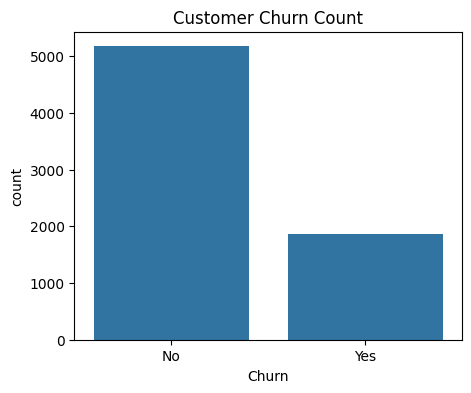

In [33]:
# CHURN COUNT PLOT
plt.figure(figsize=(5,4))

sns.countplot(x=df['Churn'])

plt.title("Customer Churn Count")

plt.show()

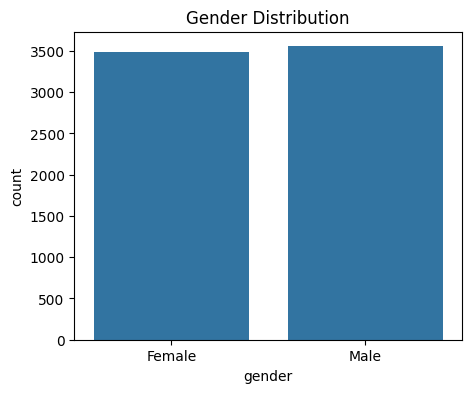

In [19]:
# GENDER DISTRIBUTION
plt.figure(figsize=(5,4))

sns.countplot(x=df['gender'])

plt.title("Gender Distribution")

plt.show()

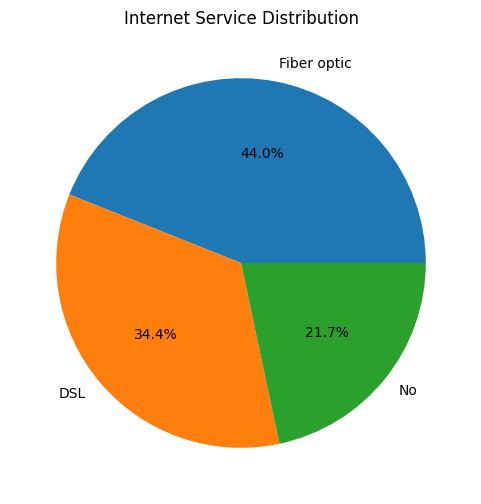

In [34]:
# INTERNET SERVICE DISTRIBUTION

internet_count = df['InternetService'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    internet_count,
    labels=internet_count.index,
    autopct='%1.1f%%'
)

plt.title('Internet Service Distribution')

plt.show()

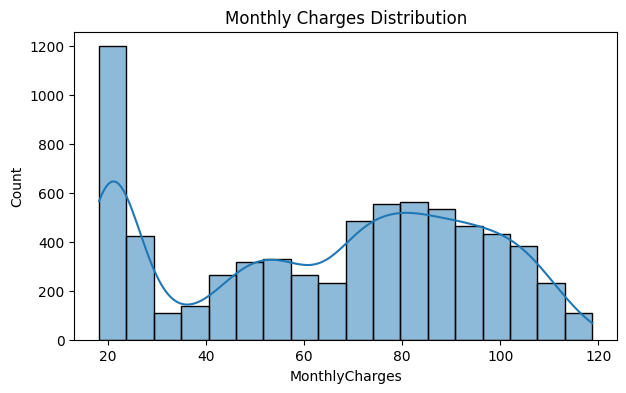

In [21]:
# MONTHLY CHARGES DISTRIBUTION
plt.figure(figsize=(7,4))

sns.histplot(df['MonthlyCharges'], kde=True)

plt.title("Monthly Charges Distribution")

plt.show()

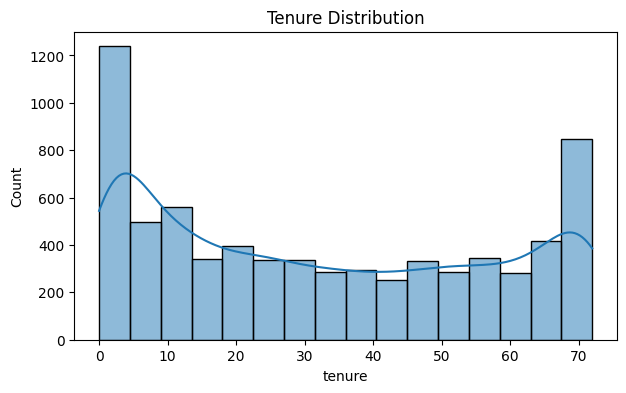

In [22]:
# TENURE DISTRIBUTION

plt.figure(figsize=(7,4))

sns.histplot(df['tenure'], kde=True)

plt.title("Tenure Distribution")

plt.show()


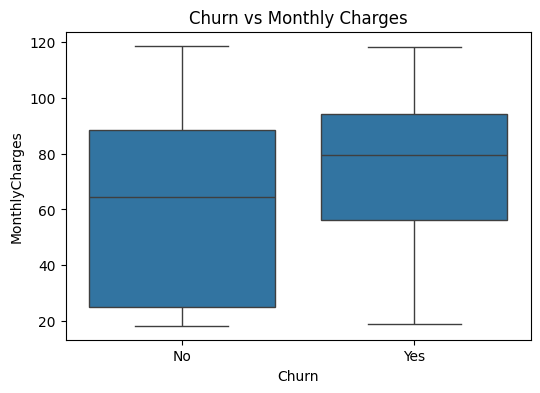

In [23]:
# CHURN VS MONTHLY CHARGES
plt.figure(figsize=(6,4))

sns.boxplot(x=df['Churn'], y=df['MonthlyCharges'])

plt.title("Churn vs Monthly Charges")

plt.show()


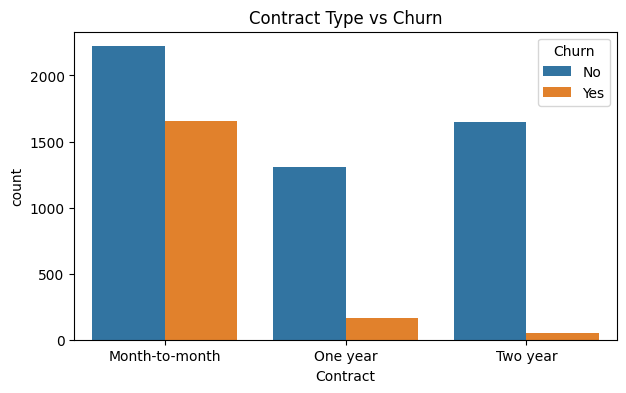

In [24]:
# CONTRACT TYPE VS CHURN
plt.figure(figsize=(7,4))

sns.countplot(x=df['Contract'], hue=df['Churn'])

plt.title("Contract Type vs Churn")

plt.show()

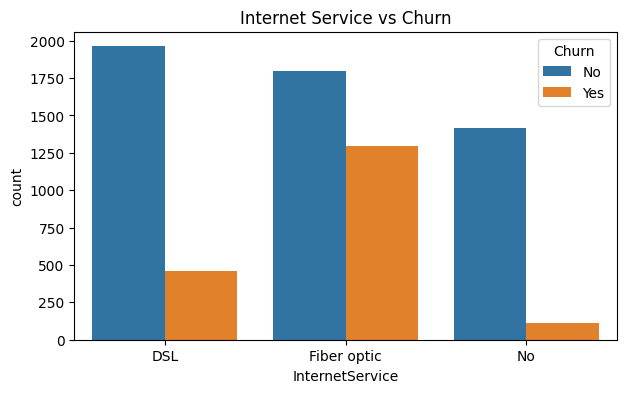

In [25]:
# INTERNET SERVICE VS CHURN

plt.figure(figsize=(7,4))

sns.countplot(x=df['InternetService'], hue=df['Churn'])

plt.title("Internet Service vs Churn")

plt.show()

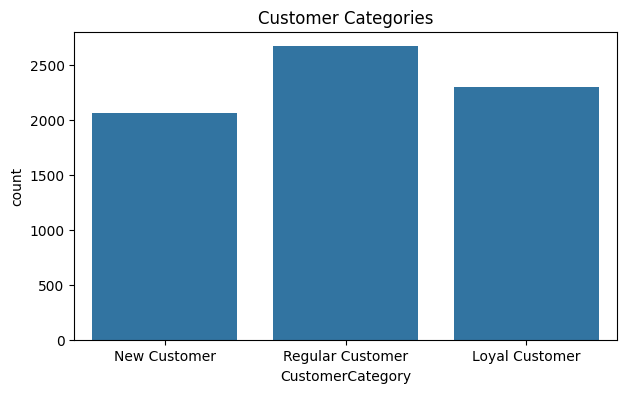

In [30]:
# CUSTOMER CATEGORY COUNT

plt.figure(figsize=(7,4))

sns.countplot(x=df['CustomerCategory'])

plt.title("Customer Categories")

plt.show()